[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/PhysML/blob/main/tutorial_04_overfitting.ipynb)

In [4]:
# Imports for the overfitting and regularization demonstration.
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss

rng = np.random.default_rng(7)

In [5]:
# =============================================================================
# PART A — Build a dataset that is easy to overfit
# =============================================================================
# High-dimensional, small dataset: worst-case scenario for overfitting.
# Physics context: you have 20 detector features per event but only 300
# labelled events (expensive to label by hand / run simulations).

N_TOTAL  = 300
N_FEATS  = 20          # 20 features — but only 3 are actually informative!

# True signal depends only on features 0, 1, 2:
def true_signal(X):
    return (X[:, 0]**2 + X[:, 1] - 0.5*X[:, 2] > 0.3).astype(float)

X_raw = rng.normal(0, 1, (N_TOTAL, N_FEATS))
y_raw = true_signal(X_raw)
# Add label noise (10% of labels flipped — realistic for crowdsourced labels)
flip_mask = rng.random(N_TOTAL) < 0.10
y_raw[flip_mask] = 1 - y_raw[flip_mask]

# Three-way split: 70 / 15 / 15
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=0, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=0, stratify=y_trainval)
# (0.176 * 0.85 ≈ 0.15 of total)

print("=" * 60)
print("  PART A — Dataset")
print("=" * 60)
print(f"  Total events  : {N_TOTAL}")
print(f"  Features      : {N_FEATS}  (only 3 are informative!)")
print(f"  Train   set   : {len(X_train)} events")
print(f"  Val     set   : {len(X_val)} events")
print(f"  Test    set   : {len(X_test)} events")
print(f"  Label noise   : 10%\n")

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_vl = scaler.transform(X_val)
X_te = scaler.transform(X_test)

  PART A — Dataset
  Total events  : 300
  Features      : 20  (only 3 are informative!)
  Train   set   : 210 events
  Val     set   : 45 events
  Test    set   : 45 events
  Label noise   : 10%



In [6]:
# =============================================================================
# PART B — Show overfitting happening in real time
# =============================================================================
print("=" * 60)
print("  PART B — Training a model until it overfits")
print("=" * 60)

# Train a large MLP epoch by epoch, recording train and val loss
big_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 128, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1,           # we call fit() repeatedly to track curves
    warm_start=True,      # keeps weights between calls
    random_state=0,
)

train_losses, val_losses, val_aucs = [], [], []
N_EPOCHS = 300

for epoch in range(N_EPOCHS):
    # We intentionally run 1 epoch per fit() call; suppress the expected warning.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        big_mlp.fit(X_tr, y_train)

    p_train = big_mlp.predict_proba(X_tr)[:, 1]
    p_val   = big_mlp.predict_proba(X_vl)[:, 1]
    train_losses.append(log_loss(y_train, p_train))
    val_losses.append(  log_loss(y_val,   p_val))
    val_aucs.append(    roc_auc_score(y_val, p_val))

best_epoch = int(np.argmin(val_losses))
print(f"  Best epoch (min val loss) : {best_epoch}")
print(f"  Train loss at best epoch  : {train_losses[best_epoch]:.4f}")
print(f"  Val   loss at best epoch  : {val_losses[best_epoch]:.4f}")
print(f"  Val AUC  at best epoch    : {val_aucs[best_epoch]:.4f}")
print(f"  Train loss at epoch {N_EPOCHS}   : {train_losses[-1]:.4f}")
print(f"  Val   loss at epoch {N_EPOCHS}   : {val_losses[-1]:.4f}  ← much higher!")
print(f"  → Overfit gap = {val_losses[-1] - train_losses[-1]:.4f}\n")

  PART B — Training a model until it overfits
  Best epoch (min val loss) : 10
  Train loss at best epoch  : 0.3990
  Val   loss at best epoch  : 0.6188
  Val AUC  at best epoch    : 0.6872
  Train loss at epoch 300   : 0.0004
  Val   loss at epoch 300   : 2.8929  ← much higher!
  → Overfit gap = 2.8925



In [7]:
# =============================================================================
# PART C — Cures for overfitting
# =============================================================================
print("=" * 60)
print("  PART C — Regularisation techniques")
print("=" * 60)

results = {}

# ── 1. Baseline: no regularisation ──────────────────────────────────────────
m1 = MLPClassifier(hidden_layer_sizes=(128,128,64), activation="relu",
                   solver="adam", max_iter=300, random_state=0)
m1.fit(X_tr, y_train)
results["No regularisation"] = {
    "train_auc": roc_auc_score(y_train, m1.predict_proba(X_tr)[:,1]),
    "val_auc":   roc_auc_score(y_val,   m1.predict_proba(X_vl)[:,1]),
    "test_auc":  roc_auc_score(y_test,  m1.predict_proba(X_te)[:,1]),
}

# ── 2. L2 weight decay (alpha = regularisation strength) ─────────────────────
# L2 adds a penalty to the loss:  L_total = L_cross_entropy + α * ||W||²
# This shrinks large weights toward zero — prevents any single connection
# from dominating and memorising one training pattern.
m2 = MLPClassifier(hidden_layer_sizes=(128,128,64), activation="relu",
                   solver="adam", max_iter=300, alpha=0.01, random_state=0)
m2.fit(X_tr, y_train)
results["L2 regularisation (α=0.01)"] = {
    "train_auc": roc_auc_score(y_train, m2.predict_proba(X_tr)[:,1]),
    "val_auc":   roc_auc_score(y_val,   m2.predict_proba(X_vl)[:,1]),
    "test_auc":  roc_auc_score(y_test,  m2.predict_proba(X_te)[:,1]),
}

# ── 3. Early stopping ─────────────────────────────────────────────────────────
# Stop training when validation loss stops improving.
# sklearn does this natively — we just pass validation_fraction.
m3 = MLPClassifier(hidden_layer_sizes=(128,128,64), activation="relu",
                   solver="adam", max_iter=500,
                   early_stopping=True,
                   validation_fraction=0.15,
                   n_iter_no_change=20,       # stop if no improvement for 20 epochs
                   random_state=0)
m3.fit(X_tr, y_train)
results[f"Early stopping (stopped @ epoch {m3.n_iter_})"] = {
    "train_auc": roc_auc_score(y_train, m3.predict_proba(X_tr)[:,1]),
    "val_auc":   roc_auc_score(y_val,   m3.predict_proba(X_vl)[:,1]),
    "test_auc":  roc_auc_score(y_test,  m3.predict_proba(X_te)[:,1]),
}

# ── 4. Smaller model (fewer parameters) ──────────────────────────────────────
# The most direct cure: reduce capacity so the model CAN'T memorise noise.
m4 = MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                   solver="adam", max_iter=300, random_state=0)
m4.fit(X_tr, y_train)
results["Smaller model (32→16)"] = {
    "train_auc": roc_auc_score(y_train, m4.predict_proba(X_tr)[:,1]),
    "val_auc":   roc_auc_score(y_val,   m4.predict_proba(X_vl)[:,1]),
    "test_auc":  roc_auc_score(y_test,  m4.predict_proba(X_te)[:,1]),
}

# ── 5. L2 + early stopping combined ─────────────────────────────────────────
m5 = MLPClassifier(hidden_layer_sizes=(128,128,64), activation="relu",
                   solver="adam", max_iter=500, alpha=0.01,
                   early_stopping=True, validation_fraction=0.15,
                   n_iter_no_change=20, random_state=0)
m5.fit(X_tr, y_train)
results[f"L2 + early stopping (epoch {m5.n_iter_})"] = {
    "train_auc": roc_auc_score(y_train, m5.predict_proba(X_tr)[:,1]),
    "val_auc":   roc_auc_score(y_val,   m5.predict_proba(X_vl)[:,1]),
    "test_auc":  roc_auc_score(y_test,  m5.predict_proba(X_te)[:,1]),
}

print(f"\n  {'Method':<42} {'Train AUC':>10} {'Val AUC':>10} {'Test AUC':>10}  {'Gap':>8}")
print("  " + "─" * 84)
for name, r in results.items():
    gap = r["train_auc"] - r["val_auc"]
    flag = " ← OVERFIT" if gap > 0.08 else " ← best" if r["val_auc"] == max(v["val_auc"] for v in results.values()) else ""
    print(f"  {name:<42} {r['train_auc']:>10.4f} {r['val_auc']:>10.4f} {r['test_auc']:>10.4f}  {gap:>8.4f}{flag}")

  PART C — Regularisation techniques


/home/waleed/micromamba/envs/pytorch/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



  Method                                      Train AUC    Val AUC   Test AUC       Gap
  ────────────────────────────────────────────────────────────────────────────────────
  No regularisation                              1.0000     0.6296     0.7881    0.3704 ← OVERFIT
  L2 regularisation (α=0.01)                     1.0000     0.6276     0.7901    0.3724 ← OVERFIT
  Early stopping (stopped @ epoch 61)            0.9803     0.7016     0.8189    0.2786 ← OVERFIT
  Smaller model (32→16)                          0.9985     0.6934     0.8107    0.3051 ← OVERFIT
  L2 + early stopping (epoch 61)                 0.9802     0.6996     0.8251    0.2806 ← OVERFIT


In [8]:
# =============================================================================
# PART D — Learning curves: how much data do we need?
# =============================================================================
print("\n" + "=" * 60)
print("  PART D — Learning curves (data efficiency)")
print("=" * 60)
print("""
A learning curve shows train and val loss as a function of
how many training samples we use.

If train >> val at all sample sizes → overfitting, need more data
  or stronger regularisation.
If both are high at all sample sizes → underfitting, need bigger model.
If they converge as N grows → you have enough data and the right model.

In particle physics / GW astronomy, labelled events are expensive.
Learning curves tell you when it's worth running more simulations.
""")


  PART D — Learning curves (data efficiency)

A learning curve shows train and val loss as a function of
how many training samples we use.

If train >> val at all sample sizes → overfitting, need more data
  or stronger regularisation.
If both are high at all sample sizes → underfitting, need bigger model.
If they converge as N grows → you have enough data and the right model.

In particle physics / GW astronomy, labelled events are expensive.
Learning curves tell you when it's worth running more simulations.



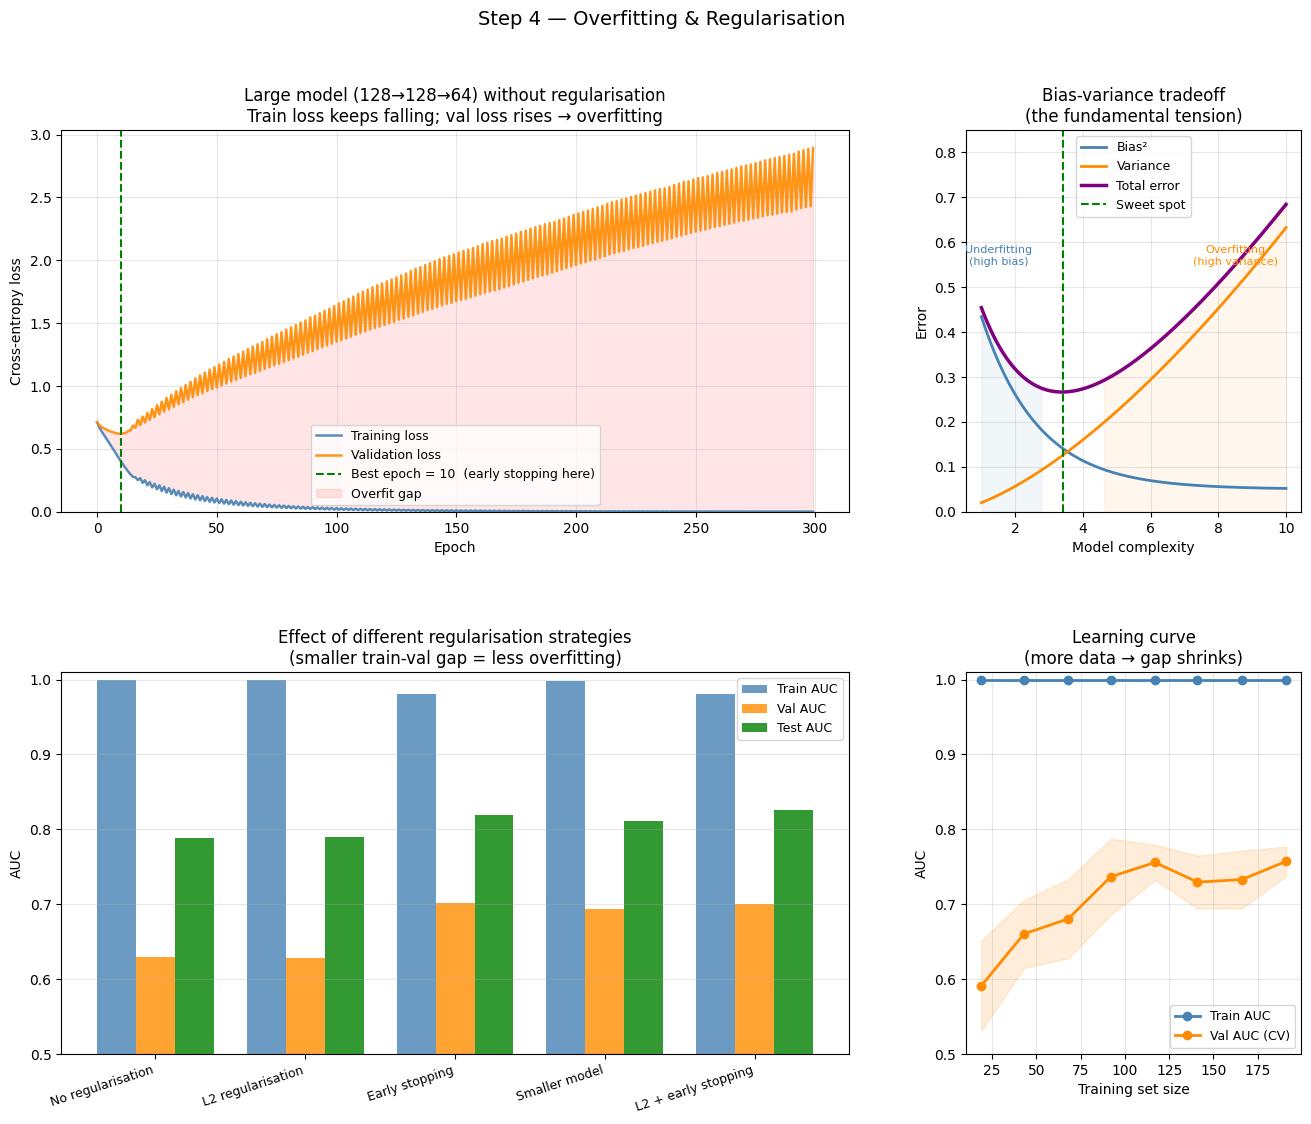


Plots saved to step4_overfitting.png


In [9]:
# =============================================================================
# PART E — Visualise
# =============================================================================

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Step 4 — Overfitting & Regularisation", fontsize=14)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── 1. Train vs Val loss curves ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(train_losses, color="steelblue",  lw=1.8, label="Training loss",   alpha=0.9)
ax1.plot(val_losses,   color="darkorange", lw=1.8, label="Validation loss", alpha=0.9)
ax1.axvline(best_epoch, color="green", lw=1.5, linestyle="--",
            label=f"Best epoch = {best_epoch}  (early stopping here)")
ax1.fill_between(range(N_EPOCHS), train_losses, val_losses,
                 alpha=0.10, color="red", label="Overfit gap")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("Large model (128→128→64) without regularisation\nTrain loss keeps falling; val loss rises → overfitting")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.set_ylim(0, max(val_losses) * 1.05)

# ── 2. Bias-variance schematic ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
c_axis = np.linspace(1, 10, 200)
bias_sq = 0.7 * np.exp(-0.6 * c_axis) + 0.05
variance = 0.02 * c_axis**1.5
total    = bias_sq + variance
ax2.plot(c_axis, bias_sq,  color="steelblue",   lw=2,   label="Bias²")
ax2.plot(c_axis, variance, color="darkorange",  lw=2,   label="Variance")
ax2.plot(c_axis, total,    color="purple",       lw=2.5, label="Total error")
ax2.axvline(c_axis[np.argmin(total)], color="green", lw=1.5,
            linestyle="--", label="Sweet spot")
ax2.fill_between(c_axis[:40],  0, total[:40],  alpha=0.07, color="steelblue")
ax2.fill_between(c_axis[80:],  0, total[80:],  alpha=0.07, color="darkorange")
ax2.text(1.5,  0.55, "Underfitting\n(high bias)", fontsize=8, color="steelblue",  ha="center")
ax2.text(8.5,  0.55, "Overfitting\n(high variance)", fontsize=8, color="darkorange", ha="center")
ax2.set_xlabel("Model complexity"); ax2.set_ylabel("Error")
ax2.set_title("Bias-variance tradeoff\n(the fundamental tension)")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3); ax2.set_ylim(0, 0.85)

# ── 3. Regularisation comparison bar chart ────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
names     = list(results.keys())
train_auc = [results[n]["train_auc"] for n in names]
val_auc   = [results[n]["val_auc"]   for n in names]
test_auc  = [results[n]["test_auc"]  for n in names]
x_pos = np.arange(len(names))
w = 0.26
ax3.bar(x_pos - w,   train_auc, w, label="Train AUC", color="steelblue",  alpha=0.8)
ax3.bar(x_pos,       val_auc,   w, label="Val AUC",   color="darkorange", alpha=0.8)
ax3.bar(x_pos + w,   test_auc,  w, label="Test AUC",  color="green",       alpha=0.8)
ax3.set_xticks(x_pos)
ax3.set_xticklabels([n.split("(")[0].strip() for n in names], rotation=18, ha="right", fontsize=9)
ax3.set_ylim(0.5, 1.01); ax3.set_ylabel("AUC")
ax3.set_title("Effect of different regularisation strategies\n(smaller train-val gap = less overfitting)")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3, axis="y")
ax3.axhline(0.5, color="gray", lw=0.8, linestyle=":")

# ── 4. Learning curve for best model ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
best_pipe = Pipeline([("scaler", StandardScaler()),
                      ("clf", MLPClassifier(hidden_layer_sizes=(128,128,64),
                                            activation="relu", solver="adam",
                                            max_iter=300, alpha=0.01,
                                            random_state=0))])
train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_trainval, y_trainval,
    cv=4,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="roc_auc",
    n_jobs=-1,
)
tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
vl_mean, vl_std = val_scores.mean(1),  val_scores.std(1)

ax4.plot(train_sizes, tr_mean, "o-", color="steelblue",  lw=2, label="Train AUC")
ax4.plot(train_sizes, vl_mean, "o-", color="darkorange", lw=2, label="Val AUC (CV)")
ax4.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color="steelblue")
ax4.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=0.15, color="darkorange")
ax4.set_xlabel("Training set size")
ax4.set_ylabel("AUC")
ax4.set_title("Learning curve\n(more data → gap shrinks)")
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
ax4.set_ylim(0.5, 1.01)

plt.savefig("./step4_overfitting.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("\nPlots saved to step4_overfitting.png")

In [10]:
# =============================================================================
# PART F — The golden rule: report test AUC only once
# =============================================================================
print("\n" + "=" * 60)
print("  PART F — Final model selection & test evaluation")
print("=" * 60)

# We pick the best model based on VAL AUC, never test AUC.
best_name = max(results, key=lambda n: results[n]["val_auc"])
best_result = results[best_name]
print(f"\n  Best model (by val AUC): {best_name}")
print(f"  Final TEST AUC         : {best_result['test_auc']:.4f}")
print("""
  This is the number we report in the paper / analysis note.
  If we had tuned on the test set, the number would be
  optimistically biased and wouldn't reflect real performance.
""")


  PART F — Final model selection & test evaluation

  Best model (by val AUC): Early stopping (stopped @ epoch 61)
  Final TEST AUC         : 0.8189

  This is the number we report in the paper / analysis note.
  If we had tuned on the test set, the number would be
  optimistically biased and wouldn't reflect real performance.



In [11]:
# =============================================================================
# PART G — Key takeaways
# =============================================================================
print("=" * 60)
print("  KEY TAKEAWAYS — STEP 4")
print("=" * 60)
print("""
1. OVERFITTING = low train loss, high validation loss.
   The model has memorised noise instead of learning the signal.

2. THE THREE-WAY SPLIT:
   Train → update θ.
   Validation → pick hyperparameters (architecture, α, learning rate).
   Test → report ONCE. Never tune on it.

3. REGULARISATION TOOLBOX:
   L2 (weight decay):  penalises large weights.  L_total = L + α||W||²
   L1 (Lasso):         penalises |W|, forces sparsity (feature selection).
   Dropout:            randomly zero out neurons during training (PyTorch/TF).
   Early stopping:     stop when val loss stops improving.
   Smaller model:      reduce capacity so it can't memorise.
   More data:          the only cure that doesn't cost model quality.

4. LEARNING CURVES tell you which problem you have:
   Both curves high → underfitting (bigger model or more features).
   Gap is large    → overfitting  (regularise or get more data).
   Curves converge → you're in the sweet spot.

5. PHYSICS ANALOGY:
   Overfitting is fitting a degree-15 polynomial to 20 noisy points.
   L2 regularisation = Tikhonov regularisation in inverse problems.
   You've almost certainly used it — it's the same math.

UP NEXT — STEP 5 (the bridge to normalising flows):
  "What if, instead of predicting a label, we want to learn
   the full PROBABILITY DISTRIBUTION p(x) of the data?"
  → Density estimation → generative models → normalising flows.
  This is where everything changes.
""")

  KEY TAKEAWAYS — STEP 4

1. OVERFITTING = low train loss, high validation loss.
   The model has memorised noise instead of learning the signal.

2. THE THREE-WAY SPLIT:
   Train → update θ.
   Validation → pick hyperparameters (architecture, α, learning rate).
   Test → report ONCE. Never tune on it.

3. REGULARISATION TOOLBOX:
   L2 (weight decay):  penalises large weights.  L_total = L + α||W||²
   L1 (Lasso):         penalises |W|, forces sparsity (feature selection).
   Dropout:            randomly zero out neurons during training (PyTorch/TF).
   Early stopping:     stop when val loss stops improving.
   Smaller model:      reduce capacity so it can't memorise.
   More data:          the only cure that doesn't cost model quality.

4. LEARNING CURVES tell you which problem you have:
   Both curves high → underfitting (bigger model or more features).
   Gap is large    → overfitting  (regularise or get more data).
   Curves converge → you're in the sweet spot.

5. PHYSICS ANALOGY: